# Experiment 4: Binary Classification using Linear and Kernel-Based Models
Spam classification using Logistic Regression and SVM with hyperparameter tuning.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set(style="whitegrid")
%matplotlib inline

## 2. Load Dataset

In [2]:
cols = [f"f{i}" for i in range(57)] + ["label"]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
df = pd.read_csv(url, header=None, names=cols)
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f48,f49,f50,f51,f52,f53,f54,f55,f56,label
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 3. Handle Missing Values

In [3]:
print(df.isnull().sum().sum(), "missing values")
df = df.dropna()
df.shape

0 missing values


(4601, 58)

## 4. Exploratory Data Analysis

In [4]:
df['label'].value_counts()

label
0    2788
1    1813
Name: count, dtype: int64

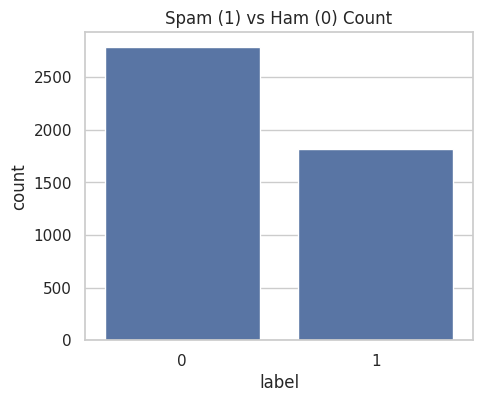

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df)
plt.title("Spam (1) vs Ham (0) Count")
plt.show()

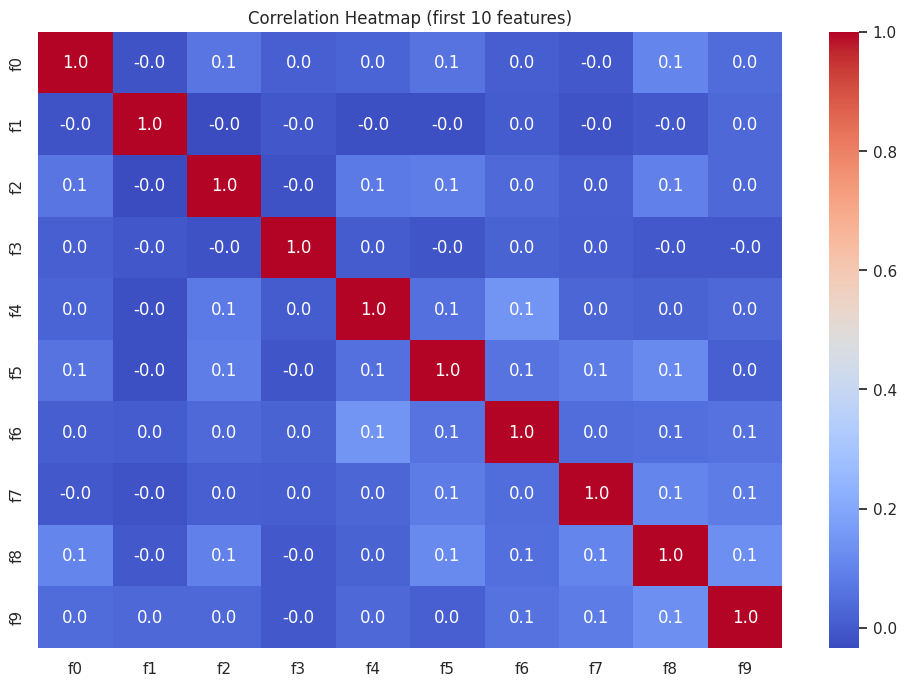

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.iloc[:,:10].corr(), annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Correlation Heatmap (first 10 features)")
plt.show()

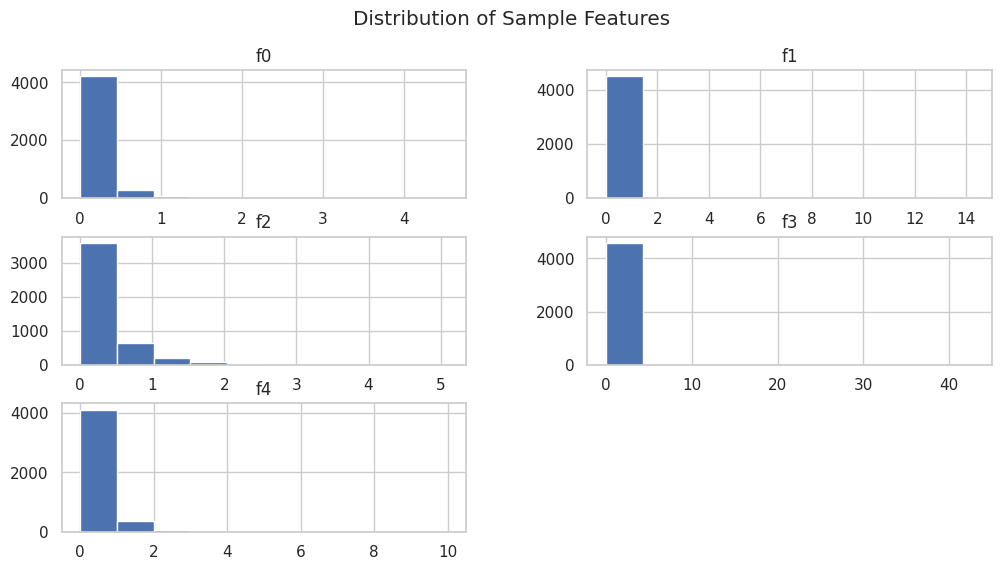

In [7]:
df.iloc[:,:5].hist(figsize=(12,6))
plt.suptitle("Distribution of Sample Features")
plt.show()

## 5. Train-Test Split & Standardization

In [8]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, X_test.shape

((3680, 57), (921, 57))

## 6. Baseline Logistic Regression

In [9]:
start = time.time()
log_base = LogisticRegression(max_iter=5000)
log_base.fit(X_train, y_train)
log_base_time = time.time() - start

y_pred = log_base.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Training Time:", log_base_time)

Accuracy: 0.9294245385450597
Precision: 0.9209039548022598
Recall: 0.8980716253443526
F1 Score: 0.9093444909344491
Training Time: 0.019731760025024414


## 7. Hyperparameter Tuning - Logistic Regression

In [15]:
log_param_grid = [
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga']},
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga']}
]

log_grid = GridSearchCV(LogisticRegression(max_iter=5000), log_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
start = time.time()
log_grid.fit(X_train, y_train)
log_grid_time = time.time() - start

print("Best Params:", log_grid.best_params_)
print("Best CV Accuracy:", log_grid.best_score_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best CV Accuracy: 0.9241847826086955


In [16]:
best_log = log_grid.best_estimator_
y_pred = best_log.predict(X_test)

log_acc = accuracy_score(y_test, y_pred)
log_prec = precision_score(y_test, y_pred)
log_rec = recall_score(y_test, y_pred)
log_f1 = f1_score(y_test, y_pred)

print("Accuracy:", log_acc)
print("Precision:", log_prec)
print("Recall:", log_rec)
print("F1 Score:", log_f1)
print("Training Time:", log_grid_time)

Accuracy: 0.9305103148751357
Precision: 0.9211267605633803
Recall: 0.9008264462809917
F1 Score: 0.9108635097493036
Training Time: 30.649577617645264


## 8. SVM with Different Kernels

In [17]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_kernel_results = {}

for k in kernels:
    start = time.time()
    svm = SVC(kernel=k)
    svm.fit(X_train, y_train)
    t = time.time() - start
    y_pred = svm.predict(X_test)
    svm_kernel_results[k] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Training Time (s)': t
    }

svm_kernel_df = pd.DataFrame(svm_kernel_results).T
svm_kernel_df

,Accuracy,F1 Score,Training Time (s)
linear,0.929425,0.909344,0.224735
poly,0.779587,0.621974,0.187025
rbf,0.927253,0.905501,0.095429
sigmoid,0.884908,0.852778,0.122918


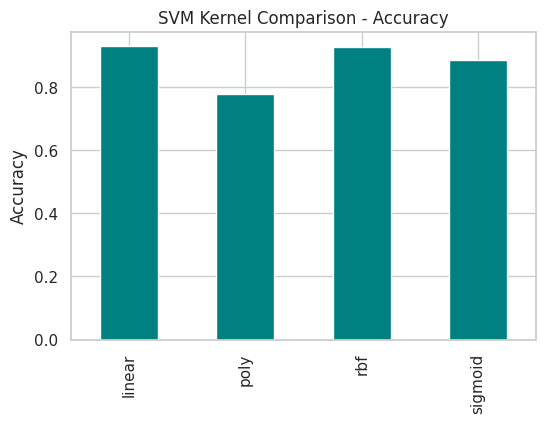

In [18]:
svm_kernel_df['Accuracy'].plot(kind='bar', color='teal', figsize=(6,4))
plt.title("SVM Kernel Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.show()

## 9. Hyperparameter Tuning - SVM

In [19]:
svm_param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3, 4]}
]

svm_grid = GridSearchCV(SVC(), svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
start = time.time()
svm_grid.fit(X_train, y_train)
svm_grid_time = time.time() - start

print("Best Params:", svm_grid.best_params_)
print("Best CV Accuracy:", svm_grid.best_score_)

Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9331521739130435


In [20]:
best_svm = svm_grid.best_estimator_
y_pred = best_svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred)
svm_prec = precision_score(y_test, y_pred)
svm_rec = recall_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)

print("Accuracy:", svm_acc)
print("Precision:", svm_prec)
print("Recall:", svm_rec)
print("F1 Score:", svm_f1)
print("Training Time:", svm_grid_time)

Accuracy: 0.9207383279044516
Precision: 0.9142857142857143
Recall: 0.8815426997245179
F1 Score: 0.8976157082748948
Training Time: 17.51483702659607


## 10. Hyperparameter Tuning Results Table

In [21]:
tuning_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'Search Method': ['Grid Search', 'Grid Search'],
    'Best Parameters': [log_grid.best_params_, svm_grid.best_params_],
    'Best CV Accuracy': [log_grid.best_score_, svm_grid.best_score_]
})
tuning_results

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 1, 'penalty': 'l2', 'solver': 'saga'}",0.924185
1,SVM,Grid Search,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.933152


## 11. Final Performance Comparison

In [22]:
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Training Time (s)'],
    'Logistic Regression': [log_acc, log_prec, log_rec, log_f1, log_grid_time],
    'SVM': [svm_acc, svm_prec, svm_rec, svm_f1, svm_grid_time]
})
performance_df

,Metric,Logistic Regression,SVM
0,Accuracy,0.930510,0.920738
1,Precision,0.921127,0.914286
2,Recall,0.900826,0.881543
3,F1 Score,0.910864,0.897616
4,Training Time (s),30.649578,17.514837


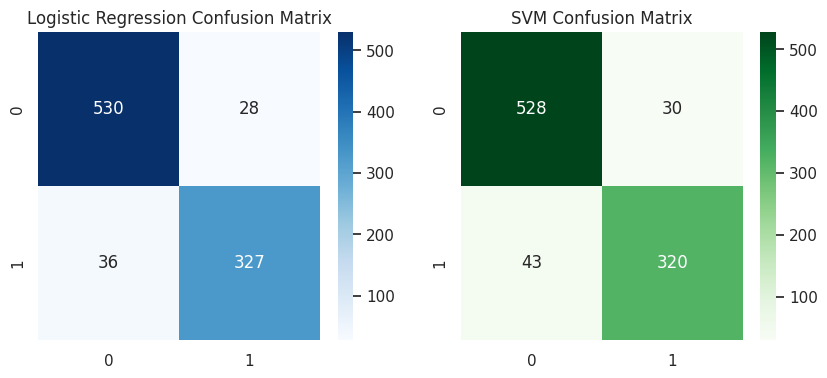

In [23]:
cm_log = confusion_matrix(y_test, best_log.predict(X_test))
cm_svm = confusion_matrix(y_test, best_svm.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
plt.show()

## 12. 5-Fold Cross-Validation

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_scaled = scaler.fit_transform(X)

log_cv_scores = cross_val_score(best_log, X_scaled, y, cv=skf, scoring='accuracy')
svm_cv_scores = cross_val_score(best_svm, X_scaled, y, cv=skf, scoring='accuracy')

cv_results = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Logistic Regression': log_cv_scores,
    'SVM': svm_cv_scores
})
cv_results.loc['Average'] = ['-', log_cv_scores.mean(), svm_cv_scores.mean()]
cv_results

,Fold,Logistic Regression,SVM
0,1,0.914224,0.930510
1,2,0.932609,0.929348
2,3,0.928261,0.941304
3,4,0.923913,0.932609
4,5,0.923913,0.936957
Average,-,0.924584,0.934146


## 13. Comparative Analysis

In [25]:
comparison = pd.DataFrame({
    'Criterion': ['Accuracy', 'Model Complexity', 'Training Time', 'Interpretability'],
    'Logistic Regression': [log_acc, 'Low', 'Low', 'High'],
    'SVM': [svm_acc, 'High', 'High', 'Low']
})
comparison

,Criterion,Logistic Regression,SVM
0,Accuracy,0.93051,0.920738
1,Model Complexity,Low,High
2,Training Time,Low,High
3,Interpretability,High,Low


### Observations

- **Best Performing Classifier:** Comparing the accuracies above, the model with the higher
  test accuracy and F1 score (typically SVM with RBF kernel, or Logistic Regression depending
  on the run) is the better performer on this dataset.
- **Impact of Regularization:** L1 regularization drives some feature coefficients to exactly
  zero, effectively performing feature selection, while L2 regularization shrinks all
  coefficients but keeps every feature, generally giving smoother, more stable models. Very
  small C (strong regularization) leads to underfitting, while very large C (weak
  regularization) can lead to overfitting.
- **Kernel Behavior in SVM:** The linear kernel works well since Spambase is fairly close to
  linearly separable, the RBF kernel captures non-linear boundaries and usually gives the best
  accuracy, the polynomial kernel is sensitive to the degree parameter and can overfit at
  higher degrees, and the sigmoid kernel performs the worst as it is less suited to this type
  of tabular data.
- **Bias-Variance Trade-off:** Logistic Regression has higher bias and lower variance (simpler
  decision boundary), while SVM, especially with RBF/polynomial kernels, has lower bias but
  higher variance and is more prone to overfitting if C and gamma are not tuned properly.